# Expresión Regular

recursos complementarios: https://blog.appsignal.com/2025/01/15/how-to-use-regular-expressions-in-python.html

## Módulo re


Una expresión regular (regex) es un patrón de búsqueda que le indica a Python qué texto encontrar dentro de una cadena. En lugar de buscar una palabra exacta, describe la forma o estructura que tiene el texto.

In [ ]:
import re

## ¿Qué es un Raw String?

En Python, los patrones regex se escriben usando cadenas crudas (raw strings) agregando una r antes de las comillas. Esto evita que Python interprete el carácter \ como un escape común (como \n para salto de línea).

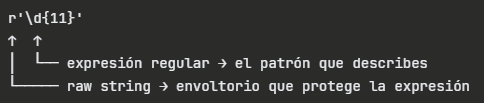

## Enlaces que te pueden ayudar a comprobar tus expresiones regulares

- https://regex-vis.com/?r=%5BA-Z%5D%5Cd%7B3%7D-%5Cd%7B4%7D
- https://regexper.com/#%5BA-Z%5D%5Cd%7B3%7D-%5Cd%7B4%7D
- https://regexr.com/
- https://regex101.com/

## Configuración Inicial

In [1]:
import re

text = "Factura E001-5834 RUC: 20610320351 Total: S/ 20.00"

## Extraer Número de RUC

In [3]:
# Buscar el patrón de 11 dígitos
resultado = re.search(r'\d{11}', text)

if resultado:
    print("Objeto Match:", resultado)
    print("Valor extraído:", resultado.group())

Objeto Match: <re.Match object; span=(23, 34), match='20610320351'>
Valor extraído: 20610320351


In [5]:
help(re.search)

Help on function search in module re:

search(pattern, string, flags=0)
    Scan through string looking for a match to the pattern, returning
    a Match object, or None if no match was found.



In [4]:
help(resultado.group)

Help on built-in function group:

group(...) method of re.Match instance
    group([group1, ...]) -> str or tuple.
    Return subgroup(s) of the match by indices or names.
    For 0 returns the entire match.



## Extraer Código de Serie y Correlativo

In [6]:
# Una letra mayúscula, 3 dígitos, guion y 4 dígitos
resultado = re.search(r'[A-Z]\d{3}-\d{4}', text)

if resultado:
    print("Serie encontrada:", resultado.group())

Serie encontrada: E001-5834


## Extraer el Precio con Decimales

In [7]:
resultado = re.search(r'\d{2}\.\d{2}', text)

if resultado:
    print("Monto extraído:", resultado.group())

Monto extraído: 20.00


## Regex vs re en python

- **re**: módulo de la librería estándar (viene con Python, no se instala). Rápido y suficiente en la mayoría de los casos.
- **regex**: paquete de terceros (`pip install regex`). Se usa cuando `re` no alcanza, por ejemplo: lookbehind de longitud variable, soporte Unicode más completo (`\p{L}`) o búsqueda difusa (fuzzy matching, tolera errores tipográficos).

### Caso de OCR en facturas

In [16]:
import re
import regex

facturas_ocr = [
    "Factura E0O1-5834 RUC: 20610320351 Total: S/ 20.00",
    "Factura E002-1123 RUC: 2O610320352 Total: S/ 45.50",
    "Factura E0Ol-9981 RUC: 20610320353 Total: S/ 12.90",
    "Factura E004-4471 RUC: 20610320354 Total: S/ 8.00",
    "FacturaE005-2290RUC:20610320355Total:S/33.00",
]

# Patrón estricto: exige espacios exactos entre cada campo
patron = r"Factura (?P<serie>[A-Z]\d{3}-\d{4}) RUC: (?P<ruc>\d{11}) Total: S/ (?P<total>[\d.]+)"

print("--- Con re (estricto) ---")
for linea in facturas_ocr:
    m = re.search(patron, linea)
    print(linea[:20], "->", m.groupdict() if m else "NO MATCH")

# Patrón fuzzy: tolera errores de caracteres Y hace \s* (espacio opcional) en vez de \s+ (obligatorio)
patron_fuzzy = r"Factura\s*(?P<serie>[A-Z0-9]{4}-\d{4}){e<=1}\s*RUC:\s*(?P<ruc>[\dOl]{11}){e<=2}\s*Total:\s*S/\s*(?P<total>[\d.]+)"

print("\n--- Con regex (tolera errores de OCR y espacios faltantes) ---")
for linea in facturas_ocr:
    m = regex.search(patron_fuzzy, linea)
    print(linea[:20], "->", m.groupdict() if m else "NO MATCH")

--- Con re (estricto) ---
Factura E0O1-5834 RU -> NO MATCH
Factura E002-1123 RU -> NO MATCH
Factura E0Ol-9981 RU -> NO MATCH
Factura E004-4471 RU -> {'serie': 'E004-4471', 'ruc': '20610320354', 'total': '8.00'}
FacturaE005-2290RUC: -> NO MATCH

--- Con regex (tolera errores de OCR y espacios faltantes) ---
Factura E0O1-5834 RU -> {'serie': 'E0O1-5834', 'ruc': '20610320351', 'total': '20.00'}
Factura E002-1123 RU -> {'serie': 'E002-1123', 'ruc': '2O610320352', 'total': '45.50'}
Factura E0Ol-9981 RU -> {'serie': 'E0Ol-9981', 'ruc': '20610320353', 'total': '12.90'}
Factura E004-4471 RU -> {'serie': 'E004-4471', 'ruc': '20610320354', 'total': '8.00'}
FacturaE005-2290RUC: -> {'serie': 'E005-2290', 'ruc': '20610320355', 'total': '33.00'}
